In [1]:
# Imports
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as transforms
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

In [3]:
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, src_path)

In [4]:
from flow import Glow
from autoencoder import SpatialVAE

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [6]:
flow_model_file = "../models/flow_best.pth"
autoencoder_model_file = "../models/spatial_autoencoder.pth"
latent_data_file = "../data/latents.npz"

In [7]:
flow = torch.load(flow_model_file, weights_only=False, map_location=device)
flow.to(device)
flow.eval()

autoencoder = torch.load(autoencoder_model_file, weights_only=False, map_location=device)
autoencoder.to(device)
autoencoder.eval()

SpatialVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): SiLU()
    (2): DownBlock(
      (conv): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (norm): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act): SiLU()
      (res): Sequential(
        (0): ResBlock(
          (block): Sequential(
            (0): GroupNorm(8, 64, eps=1e-05, affine=True)
            (1): SiLU()
            (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (3): GroupNorm(8, 64, eps=1e-05, affine=True)
            (4): SiLU()
            (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          )
        )
        (1): ResBlock(
          (block): Sequential(
            (0): GroupNorm(8, 64, eps=1e-05, affine=True)
            (1): SiLU()
            (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), 

In [8]:
# load data
data = np.load(latent_data_file)
latents_tensor = torch.from_numpy(data['latents'].astype(np.float32))
latents_mean_tensor = torch.from_numpy(data['latents_mean'].astype(np.float32))
latents_std_tensor = torch.from_numpy(data['latents_std'].astype(np.float32))

In [28]:
@torch.no_grad()
def generate_faces(autoencoder, flow, n_samples=16, temperature=0.7):
    autoencoder.eval()
    flow.eval()
    device = next(autoencoder.parameters()).device

    # Glow generates spatial latents
    latent_normalized = flow.sample(n_samples, device=device, temperature=0.1)
    latent = latent_normalized * latents_std_tensor + latents_mean_tensor

    images = autoencoder.decode(latent)
    return images.cpu().clamp(0, 1)

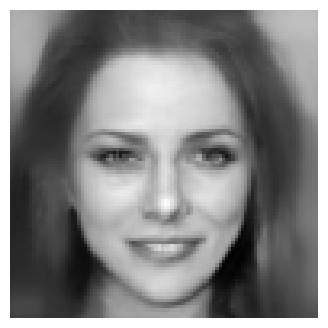

In [65]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Generate images
images = generate_faces(autoencoder, flow, n_samples=4, temperature=1.0)

# Make grid
grid = vutils.make_grid(images, nrow=4, normalize=True)

# Plot
plt.figure(figsize=(16, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")

# Save
plt.savefig("../imgs/generated_face.png", dpi=300, bbox_inches="tight", pad_inches=0)
# plt.savefig("../imgs/generated_face.pdf", bbox_inches="tight", pad_inches=0)

plt.show()